## STA 141A: Assignment 6
###  Jiawei Zhu 923312684


In [49]:
# Setup ---------------------------------------------------------------

set.seed(141)

library(tidyverse)
library(ISLR)         # for Default dataset
library(rpart)        # decision trees
library(rpart.plot)   # tree plotting
library(randomForest) # random forest


## Question 1

We will use the `mtcars` dataset to build a prediction model for fuel economy.

1. Treat `mpg` (miles per gallon) as the response and consider `wt` (weight) and `hp` (horsepower) as predictors. Split the data into a training set ($80\%$) and a test set ($20\%$) using a random split.
2. Fit the linear regression model
   $$ \text{mpg} = \beta_0 + \beta_1 \, \text{wt} + \beta_2 \, \text{hp} + \varepsilon $$
   using the training set.
3. Compute the training MSE and test MSE.
4. Briefly comment on the difference between training and test MSE.


In [50]:
# Loading and preparing the data -----------------------------------------
set.seed(141)

removing <- na.omit(mtcars)

de_mtcars <- mtcars %>%
  select(mpg, wt, hp) 

head(de_mtcars)

,mpg,wt,hp
,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,2.620,110
Mazda RX4 Wag,21.0,2.875,110
Datsun 710,22.8,2.320,93
Hornet 4 Drive,21.4,3.215,110
Hornet Sportabout,18.7,3.440,175
Valiant,18.1,3.460,105


In [51]:
# 1 (1)
set.seed(141)
n_nrow <- nrow(de_mtcars)
training_set <- sample(1:n_nrow, size = round(0.8*n_nrow), replace = FALSE)

traning <- de_mtcars[training_set,]
testing <- de_mtcars[-training_set,]
nrow(trainng)
nrow(testing)

[1] 26

[1] 6

In [52]:
# 1 (2)
set.seed(141)
linear_model <- lm(mpg ~ wt + hp, data = traning)
summary(linear_model)


Call:
lm(formula = mpg ~ wt + hp, data = traning)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2796 -1.8471 -0.0994  1.0131  5.3579 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 37.86780    1.79419  21.106  < 2e-16 ***
wt          -3.91768    0.69215  -5.660 9.21e-06 ***
hp          -0.03287    0.01015  -3.238  0.00363 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.739 on 23 degrees of freedom
Multiple R-squared:  0.8353,	Adjusted R-squared:  0.821 
F-statistic: 58.33 on 2 and 23 DF,  p-value: 9.81e-10


In [53]:
# 1 （3）
train_mse <- mean(linear_model$residuals^2)
cat("Training MSE:", train_mse, "\n")
test_predictions <- predict(linear_model, newdata = testing)
test_mse <- mean((testing$mpg - test_predictions)^2)
cat("Testing MSE:", test_mse, "\n")

Training MSE: 6.637312 
Testing MSE: 4.460499 


### 1 (4)
### The Tranining MSE is 6.63 much larger than Testing MSE 4.46.
### Although the data of Tranning MSE is lower, this result is becuase of small sample size of mtcars dataset.
### There are only 6 observatiob with 80% and 20% split
### The lower Testing MSE shows that there are 6 cars matches the realtionship between linear regression model.
### In conclusion, Although the model does a good job of generalizing to this specific test subset, the performance measures are quite susceptible to the random splitting of the data, as evidenced by the large difference between the two numbers.

## Question 2

We use the `Default` dataset from the `ISLR` package. The response `default` indicates whether a customer defaults on their credit card balance (`Yes` or `No`).

1. Convert `Default` to a tibble and create a numeric binary variable

   $$
   \texttt{default01} =
   \begin{cases}
     1 & \text{if default = "Yes"} \\
     0 & \text{if default = "No"}
   \end{cases}
   $$

2. Fit a logistic regression model with `default01` as the response and predictors `balance` and `income` using the full dataset.
3. For each observation, compute the fitted probability of default.
4. Using a classification threshold of 0.5, assign each observation to “default” (1) or “no default” (0). Compute the overall classification accuracy.
5. Now change the threshold to 0.2. Recompute the classification accuracy. Compare the accuracy under thresholds 0.5 and 0.2.


In [54]:
# 2 (1)
df_def <- Default |>
  as_tibble() |>
  mutate(default01 = ifelse(default == "Yes", 1, 0))

head(df_def)

default,student,balance,income,default01
<fct>,<fct>,<dbl>,<dbl>,<dbl>
No,No,729.5265,44361.625,0
No,Yes,817.1804,12106.135,0
No,No,1073.5492,31767.139,0
No,No,529.2506,35704.494,0
No,No,785.6559,38463.496,0
No,Yes,919.5885,7491.559,0


In [55]:
# 2 (2)
log_linear_model <- glm(default01 ~ balance + income, data = df_def, family = binomial)
summary(log_linear_model)


Call:
glm(formula = default01 ~ balance + income, family = binomial, 
    data = df_def)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.154e+01  4.348e-01 -26.545  < 2e-16 ***
balance      5.647e-03  2.274e-04  24.836  < 2e-16 ***
income       2.081e-05  4.985e-06   4.174 2.99e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2920.6  on 9999  degrees of freedom
Residual deviance: 1579.0  on 9997  degrees of freedom
AIC: 1585

Number of Fisher Scoring iterations: 8


In [56]:
# 2 (3)
fitted_probabilities <- predict(log_linear_model, type = "response")
head(fitted_probabilities)

1            2            3            4            5            6 
0.0015047280 0.0012619299 0.0080262106 0.0004059957 0.0018267237 0.0020424398

In [57]:
# 2 （4）
classifed <- ifelse(fitted_probabilities > 0.5, 1, 0)
class_accuracy <- mean(classifed == df_def$default01)
cat("Classification Accuracy:", class_accuracy, "\n")
table(classifed, df_def$default01)

Classification Accuracy: 0.9737 


         
classifed    0    1
        0 9629  225
        1   38  108

In [58]:
# 2 (5)
new_fitted <- ifelse(fitted_probabilities > 0.2, 1, 0)
new_class_accuracy <- mean(new_fitted == df_def$default01)
cat("New Classification Accuracy:", new_class_accuracy, "\n")
table(new_fitted, df_def$default01)

cimparison <- data.frame(
  Threshold = c(0.5, 0.2),
  Accuracy = c(class_accuracy, new_class_accuracy)
)
print(cimparison)

New Classification Accuracy: 0.9596 


          
new_fitted    0    1
         0 9396  133
         1  271  200

  Threshold Accuracy
1       0.5   0.9737
2       0.2   0.9596


## Question 3

We consider the `Default` dataset again.

1. Using the same dataset created in Problem 2, fit a classification tree to predict `default01` using`balance`, `income`, and `student`. You may use `rpart()` with `method = "class"`.
2. Plot the fitted tree with `rpart.plot()`.
3. Compute the overall classification accuracy of the tree on the full dataset.
4. Compare the tree’s accuracy to the logistic regression model from Problem 2 (using threshold 0.5). Which model classifies better in this dataset?

In [59]:
# 3 (1)
tree_model <- rpart(
    default01 ~ balance + income + student , 
    data = df_def, 
    method = "class",
)
summary(tree_model)

Call:
rpart(formula = default01 ~ balance + income + student, data = df_def, 
    method = "class")
  n= 10000 

          CP nsplit rel error    xerror       xstd
1 0.10810811      0 1.0000000 1.0000000 0.05387952
2 0.07807808      1 0.8918919 0.9549550 0.05269287
3 0.03603604      2 0.8138138 0.8348348 0.04936919
4 0.01000000      3 0.7777778 0.8078078 0.04858594

Variable importance
balance  income student 
     94       3       3 

Node number 1: 10000 observations,    complexity param=0.1081081
  predicted class=0  expected loss=0.0333  P(node) =1
    class counts:  9667   333
   probabilities: 0.967 0.033 
  left son=2 (9712 obs) right son=3 (288 obs)
  Primary splits:
      balance < 1800.002 to the left,  improve=166.0938000, (0 missing)
      income  < 22309.53 to the right, improve=  0.8350516, (0 missing)
      student splits as  LR,           improve=  0.8077458, (0 missing)

Node number 2: 9712 observations
  predicted class=0  expected loss=0.01760708  P(node) =0.9712
   

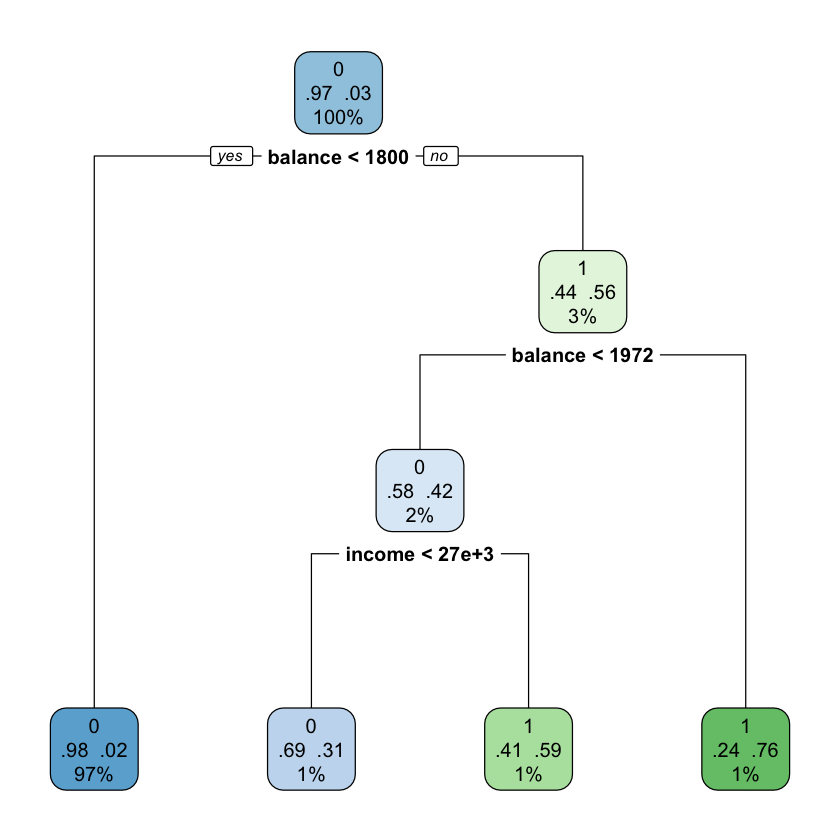

In [60]:
# 3(2)
rpart.plot(tree_model, extra = 104, type = 2, fallen.leaves = TRUE)

In [61]:
# 3 (3)
tree_predictions <- predict(tree_model, type = "class")
tree_accuracy <- mean(tree_predictions == df_def$default01)
cat("Tree Classification Accuracy:", tree_accuracy, "\n")
table(tree_predictions, df_def$default01)

Tree Classification Accuracy: 0.9741 


                
tree_predictions    0    1
               0 9611  203
               1   56  130

### 3 (4)
### The classification tree accuracy is 0.9741(97.41%). And in question 2, the logistic regression model from Problem 2 of thresold 0.5 is 0.9737. (97.37%). The classification tree accuracy model classifies better in this dataset.

## Question 4

We now fit a random forest model for the same default prediction task.

1. Using the same dataset in the previous questions, fit a random forest to predict `default01` using `balance`, `income`, and `student`. Make sure the response is treated as a factor in the model.
2. Print the random forest object and note the out-of-bag (OOB) error rate.
3. Create a variable importance plot.
4. Compute the classification accuracy of the random forest on the full dataset.
5. Compare the random forest accuracy with  the logistic regression (Question 2, threshold 0.5) and  the classification tree (Question 3). 

In [73]:
# 4 （1）
set.seed(141)
rf_fit <- randomForest(
  factor(default01) ~ balance + income + student,
    data = df_def,
    importance = TRUE
)
print(rf_fit)




Call:
 randomForest(formula = factor(default01) ~ balance + income +      student, data = df_def, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 1

        OOB estimate of  error rate: 2.78%
Confusion matrix:
     0  1 class.error
0 9627 40 0.004137788
1  238 95 0.714714715


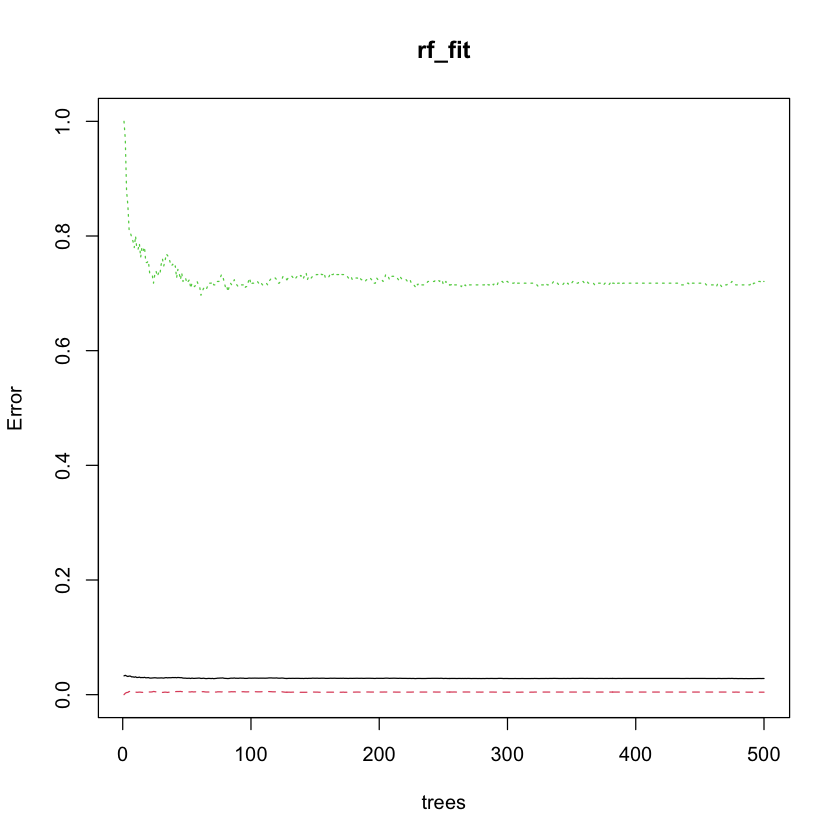

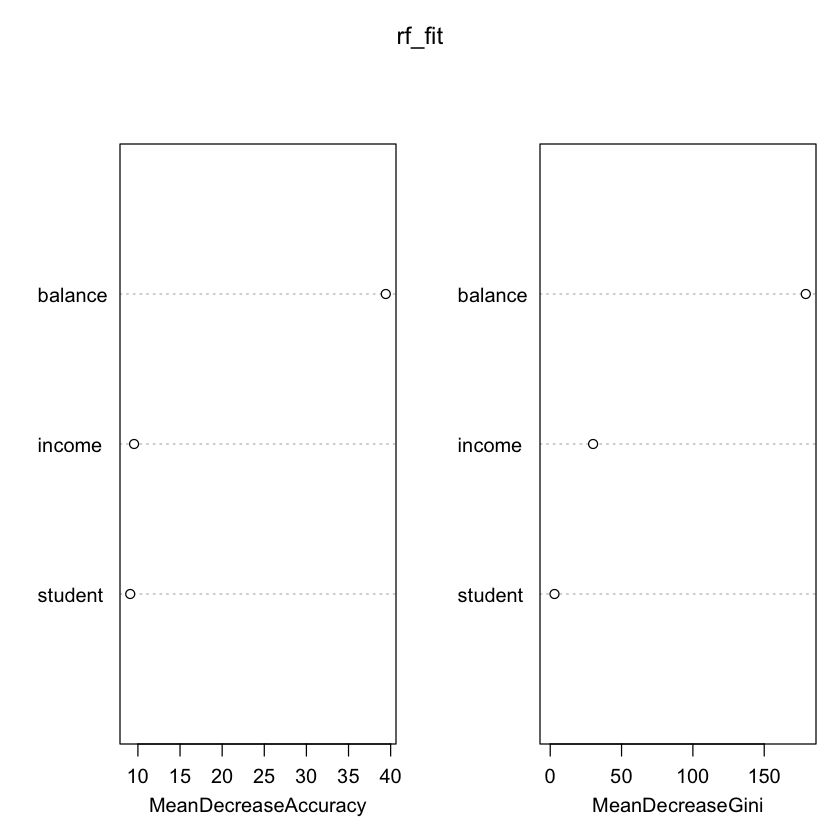

In [63]:
# 4(2) （3）
plot(rf_fit)
varImpPlot(rf_fit)

In [64]:
# 4 （4）
rf_predictions <- predict(rf_fit, newdata = df_def)
rf_accuracy <- mean(rf_predictions == df_def$default01)
cat("Random Forest Classification Accuracy:", rf_accuracy, "\n")
table(rf_predictions, df_def$default01)

Random Forest Classification Accuracy: 0.9759 


              
rf_predictions    0    1
             0 9643  217
             1   24  116

### 4 （5）

### The Random tree in Question 4 has the best accuracy on this dataset, with an accuracy 97.59%, and then the next can be Classification tree in Question 3, with an accuracy of accuracy 97.41%, and then the last is the Logisitic regression in Question 2, with an accuracy of accuracy 97.37%

## Question 5

We now compare three models for predicting default:

- Logistic regression (Problem 2),
- Classification tree (Problem 3),
- Random forest (Problem 4).

Use 5-fold cross-validation on the `Default` data.

1. Write a function `cv_error(model_type, k = 5, data = df_def)` that:
   - randomly splits the data into `k` folds,
   - for each fold, fits the specified model on the other `k-1` folds,
   - computes the misclassification rate on the held-out fold,
   - returns the average misclassification rate across folds.

   Here `model_type` is one of `"logit"`, `"tree"`, `"rf"`.

2. Use your function to compute 5-fold CV errors for all three models.


In [75]:
# 5 (1) （2）

cv_error <- function(model_type, k = 5, data = df_def) {
  set.seed(141)
  n <- nrow(data)
  new_folders <- sample(rep(1:k, length.out = n))
  all_errors <- numeric(k) 
  
  for (j in 1:k) {
    tr <- data[new_folders != j, ]
    va <- data[new_folders == j, ]
    
    if (model_type == "logit") {
      q2_fit <- glm(default01 ~ balance + income, data = tr, family = binomial)
      q2_p <- predict(q2_fit, newdata = va, type = "response")
      preds <- ifelse(q2_p > 0.5, 1, 0) # 
      
    } else if (model_type == "tree") {
      q3_fit <- rpart(default01 ~ balance + income + student, data = tr, method = "class")
      preds <- predict(q3_fit, newdata = va, type = "class")
      
    } else if (model_type == "rf") {
      q4_fit <- randomForest(factor(default01) ~ balance + income + student, data = tr)
      preds <- predict(q4_fit, newdata = va)
    }
    
    all_errors[j] <- mean(preds != va$default01)
  }
  
  return(mean(all_errors))
}

cv_logit <- cv_error("logit")
cv_tree  <- cv_error("tree")
cv_rf    <- cv_error("rf")

cat("Logistic Regression CV Error:", cv_logit, "\n")
cat("Classification Tree CV Error:", cv_tree, "\n")
cat("Random Forest CV Error:      ", cv_rf, "\n")

Logistic Regression CV Error: 0.0261 
Classification Tree CV Error: 0.0276 
Random Forest CV Error:       0.0286 
